# jaxfne Suite No. 1: Computational Biophysics

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HNXJ/jaxfne/blob/main/tutorials/jaxfne_suite_no_1_computational_biophysics.ipynb)

This tutorial shows how to configure, simulate, visualize, and inspect neural population models with the JAX-native `jaxfne` workflow:

`Configuration → construct → simulate → probe/visualize`

The examples use simulated/proxy-scale readouts inside a computational scaffold.

## Learning Objectives

1. Configure single-neuron emitter dynamics.
2. Build E/I population dynamics.
3. Compute source / field / probe readouts.
4. Tune AMPA synaptic strength with multi-objective AGSDR.

**Prerequisites:** `jaxfne`, `jax`, `matplotlib`

**Runtime target:** 3–5 minutes on CPU or Colab.

In [1]:
!pip install "jaxfne @ git+https://github.com/HNXJ/jaxfne.git@main" -q
import sys
sys.path.insert(0, '.')

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try brew install
    xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a Python library that isn't in Homebrew,
    use a virtual environment:
    
    python3 -m venv path/to/venv
    source path/to/venv/bin/activate
    python3 -m pip install xyz
    
    If you wish to install a Python application that isn't in Homebrew,
    it may be easiest to use 'pipx install xyz', which will manage a
    virtual environment for you. You can install pipx with
    
    brew install pipx
    
    You may restore the old behavior of pip by passing
    the '--break-system-packages' flag to pip, or by adding
    'break-system-pac

kages = true' to your pip.conf file. The latter
    will permanently disable this error.
    
    If you disable this error, we STRONGLY recommend that you additionally
    pass the '--user' flag to pip, or set 'user = true' in your pip.conf
    file. Failure to do this can result in a broken Homebrew installation.
    
    Read more about this behavior here: <https://peps.python.org/pep-0668/>

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detailed specification.


In [2]:
import jaxfne as jtfne, numpy as np, matplotlib.pyplot as plt, json
from pathlib import Path
from scipy import signal


## Setup


In [3]:
# Runtime configuration
DURATION_MS, DT_MS, SEED, DTYPE = 5000.0, 0.1, 42, "float32"
OUT_DIR = Path("outputs/suite_no1")
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RUN_METADATA = {"scope_status": "computational_scaffold", "readout_status": "simulated_proxy", "field_mode": "proxy_convolution_no_pde", "physical_amplitude_claim_allowed": False, "duration_ms": DURATION_MS, "dt_ms": DT_MS, "dtype": DTYPE, "seed": SEED}
json.dumps(RUN_METADATA, allow_nan=False)
print("Run metadata initialized (JSON-safe).")

Run metadata initialized (JSON-safe).


In [4]:
# Import tutorial helpers from jaxfne.tutorial_utils
from jaxfne.tutorial_utils import (
    save_png, finite_status, population_rate_hz,
    ConfigSummary, display_run_summary, plot_raster,
    plot_population_rate, plot_voltage_samples,
    plot_connectivity_matrix, plot_laminar_readout
)

## Setup (continued)


## Hodgkin-Huxley Reference Model

The Hodgkin-Huxley (HH) model is a mechanistic model of neuronal ion channel dynamics with voltage-dependent gating of sodium and potassium conductances:

$$C_m \frac{dV_m}{dt} = I_{\text{inj}} - I_{Na} - I_K - I_L$$

**Ionic currents:** $I_{Na} = g_{Na} m^3 h (V_m - E_{Na})$, $I_K = g_K n^4 (V_m - E_K)$, $I_L = g_L (V_m - E_L)$

**Gating variables** ($m$, $h$, $n$) follow: $\frac{dx}{dt} = \alpha_x(V_m)(1-x) - \beta_x(V_m) x$

**Scope:** HH emitter reference generated through the optional Jaxley bridge. **Evidence:** Simulated voltage trace for tutorial comparison. **Interpretation:** Emitter-level reference before TFNE source/readout projection. For production use, consider **jaxley.channels.HH** (Sterratt et al.). The jaxfne tutorials use simulated/proxy readouts for computational visualization.

In [5]:
from jaxfne.tutorial_utils import hh_reference_trace_jaxley
t_hh, V_hh, I_hh = hh_reference_trace_jaxley(
    duration_ms=500.0, dt_ms=0.1, current_amplitude=10.0)

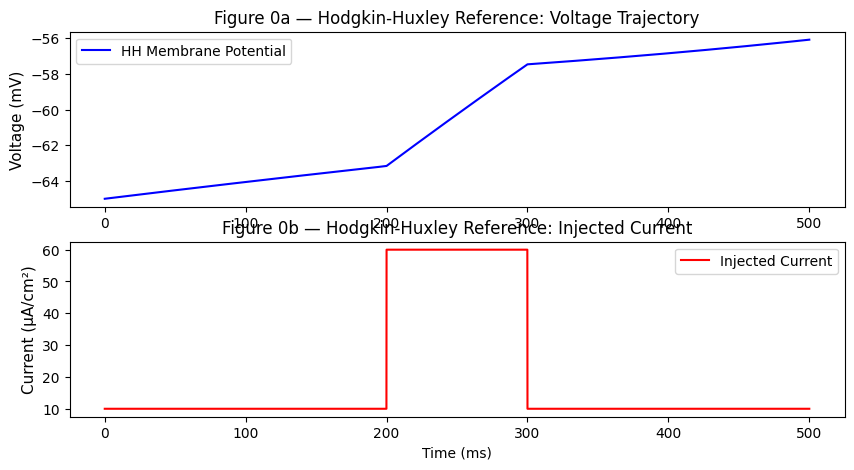

saved: outputs/suite_no1/figures/00_hh_reference.png (58.5 KB)


'outputs/suite_no1/figures/00_hh_reference.png'

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5))
ax1.plot(t_hh, V_hh, 'b-', lw=1.5, label='HH Membrane Potential')
ax1.set_ylabel('Voltage (mV)', fontsize=11)
ax1.set_title('Figure 0a — Hodgkin-Huxley Reference: Voltage Trajectory')
ax1.legend()
ax2.plot(t_hh, I_hh, 'r-', lw=1.5, label='Injected Current')
ax2.set_xlabel('Time (ms)'), ax2.set_ylabel('Current (μA/cm²)', fontsize=11)
ax2.set_title('Figure 0b — Hodgkin-Huxley Reference: Injected Current')
ax2.legend()
save_png(fig, "00_hh_reference", fig_dir=FIG_DIR, show=True)


## Section 3: Mathematical Glossary

### Izhikevich Neuron Model

The Izhikevich model is a **phenomenological** (simplified for teaching, focusing on network dynamics) model of neuronal dynamics:

$$\frac{dv_i}{dt} = 0.04 v_i^2 + 5v_i + 140 - u_i + I_i$$
$$\frac{du_i}{dt} = a_i(b_i v_i - u_i)$$

**When $v \geq 30$ mV:** reset to $c$, increment recovery by $d$.

**Parameters:**
- $v_i$: voltage-like state
- $u_i$: recovery variable  
- $I_i$: input current (combination of base drive + recurrent input)
- $a, b, c, d$: preset-dependent parameters

**Presets** (e.g., "cortical_eig") are pre-tuned parameter sets for common neuron types.

### Recurrent Input Scaffold

Each neuron receives:

$$I_i(t) = I^{\text{base}}(t) + \sum_j W_{ij} s_j(t)$$

Where:
- $I^{\text{base}}$: baseline drive
- $W_{ij}$: synaptic weight (sign determined by E/I type)
- $s_j(t)$: spike/activity signal from neuron $j$

### Proxy Readout Principle

Field quantities (LFP, CSD, etc.) are computed via **convolution-based proxies**, not PDE solvers:

$$\text{LFP-proxy}(t) = \text{convolve}(\text{sources}(t), \text{kernel})$$

This allows fast visualization without claiming physical amplitude calibration.

### Scope Boundary

All outputs in this tutorial are:
- **Computational scaffold**: a teaching model, tutorial-scale for learning and visualization
- **Proxy-scale**: designed for relative comparison, not absolute measurement
- **Phenomenological**: not mechanistically detailed biophysics


## Part 1: Single-Neuron Dynamics

**Goal:** simulate one configured emitter and inspect its state traces.

Main objects:

- `Configuration`
- emitter preset
- runtime settings
- simulated voltage/state output


In [7]:
# Part 1: Single Neuron Configuration
cfg_single = (jtfne.Configuration()
    .runtime(seed=SEED, dtype=DTYPE, duration_ms=DURATION_MS, dt_ms=DT_MS)
    .column(name="single_neuron", layers=["L2/3"], n=1)
    .cell_types({"E": 1.0})
    .connectivity(kind="none")
    .set_emitter("izhikevich", "cortical_eig")
    .probes(["spikes", "V_m", "source", "LFP-proxy"]))
print(f"Single-neuron config valid: {cfg_single.validate()['valid']}")

Single-neuron config valid: True


In [8]:
# Simulate single neuron
model_single = jtfne.construct(cfg_single)
signals_single = jtfne.simulate(model_single, duration_ms=DURATION_MS, dt_ms=DT_MS, seed=SEED)
single_spikes = np.asarray(signals_single.spikes)[:, 0]
single_V_m = np.asarray(signals_single.V_m)[:, 0]
single_sources = np.asarray(signals_single.sources)[:, 0]
single_t = np.asarray(signals_single.time_ms)
single_rate_hz = population_rate_hz(single_spikes[:, None], DT_MS)
display_run_summary("Single Neuron", single_spikes[:, None], single_V_m[:, None], DT_MS, finite_status(single_V_m, single_spikes, single_sources))


Single Neuron:
  Spikes: 54 | Shape: (50000, 1) | Rate: 10.80 Hz
  Voltage: [-76.1, 29.9] mV | Finite: True


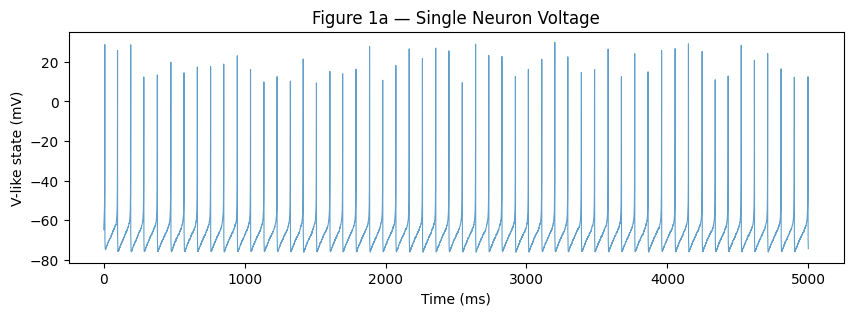

saved: outputs/suite_no1/figures/01_single_voltage_trajectory.png (58.7 KB)


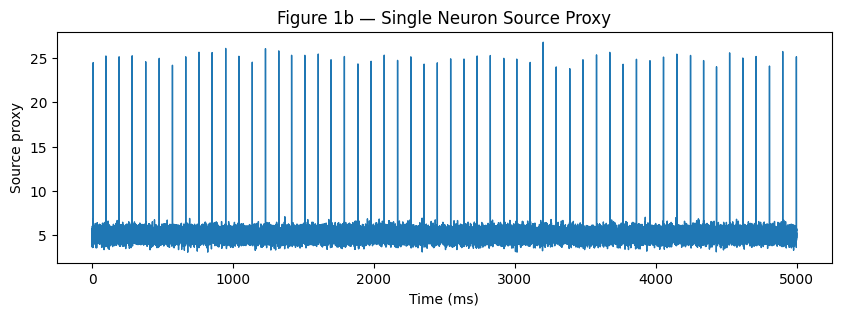

saved: outputs/suite_no1/figures/02_single_source_proxy.png (41.7 KB)


'outputs/suite_no1/figures/02_single_source_proxy.png'

In [9]:
# Visualize single neuron
fig = plot_voltage_samples(single_t, single_V_m[:, None], title="Figure 1a — Single Neuron Voltage", max_neurons=1)
save_png(fig, "01_single_voltage_trajectory", fig_dir=FIG_DIR, show=True)
fig = plt.figure(figsize=(10, 3))
ax = fig.add_subplot(111)
ax.plot(single_t, single_sources, lw=1.0)
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Source proxy")
ax.set_title("Figure 1b — Single Neuron Source Proxy")
save_png(fig, "02_single_source_proxy", fig_dir=FIG_DIR, show=True)

## Part 2: E/I Population Dynamics

**Goal:** scale from one emitter to an excitatory/inhibitory population.

This section demonstrates how population composition, connectivity, and runtime settings shape simulated spike and state trajectories.


In [10]:
# Part 2: E/PV Population Configuration
cfg_pop = (jtfne.Configuration()
    .runtime(seed=SEED + 1, dtype=DTYPE, duration_ms=DURATION_MS, dt_ms=DT_MS)
    .column(name="small_epv_pop", layers=["L2/3"], n=16)
    .cell_types({"E": 0.75, "PV": 0.25})
    .connectivity(kind="dense_signed_ei_metadata", e_to_all=0.08, i_to_all=-0.12)
    .set_emitter("izhikevich", "cortical_eig")
    .probes(["spikes", "V_m", "source", "LFP-proxy"]))
model_pop = jtfne.construct(cfg_pop)

In [11]:
# Simulate E/PV population
signals_pop = jtfne.simulate(model_pop, duration_ms=DURATION_MS, dt_ms=DT_MS, seed=SEED + 1)
pop_spikes = np.asarray(signals_pop.spikes)
pop_V_m = np.asarray(signals_pop.V_m)
pop_sources = np.asarray(signals_pop.sources)
pop_t = np.asarray(signals_pop.time_ms)
pop_rate_hz = population_rate_hz(pop_spikes, DT_MS)
display_run_summary("E/PV Population", pop_spikes, pop_V_m, DT_MS, finite_status(pop_V_m, pop_spikes, pop_sources))


E/PV Population:
  Spikes: 644 | Shape: (50000, 16) | Rate: 8.05 Hz
  Voltage: [-76.1, 30.0] mV | Finite: True


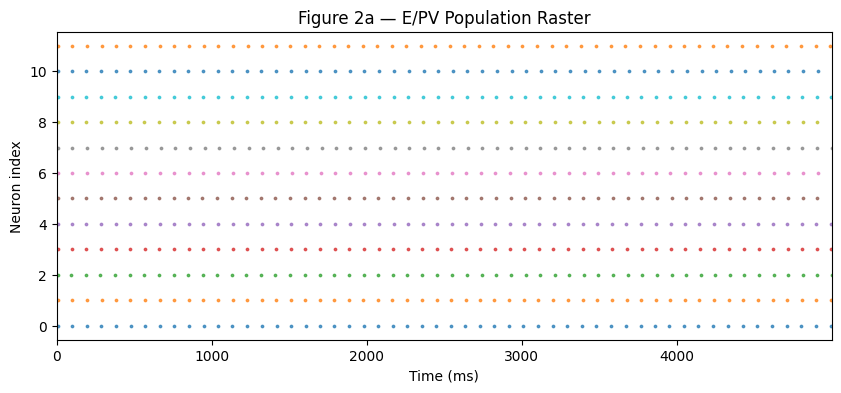

saved: outputs/suite_no1/figures/03_epv_population_raster.png (26.6 KB)


'outputs/suite_no1/figures/03_epv_population_raster.png'

In [12]:
# Visualize E/PV population
fig, ax = plt.subplots(figsize=(10, 4))
for neuron_id in range(pop_spikes.shape[1]):
    spike_times = pop_t[pop_spikes[:, neuron_id] > 0.5]
    ax.scatter(spike_times, np.full_like(spike_times, neuron_id), s=3, alpha=0.7)
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Neuron index")
ax.set_title("Figure 2a — E/PV Population Raster")
ax.set_xlim(pop_t.min(), pop_t.max())
save_png(fig, "03_epv_population_raster", fig_dir=FIG_DIR, show=True)

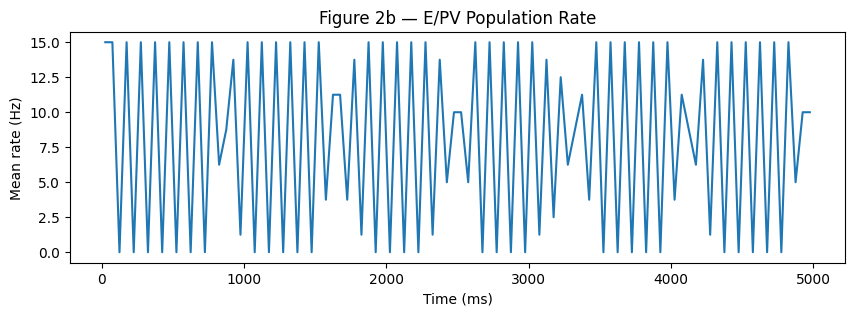

saved: outputs/suite_no1/figures/04_epv_population_rate.png (97.7 KB)


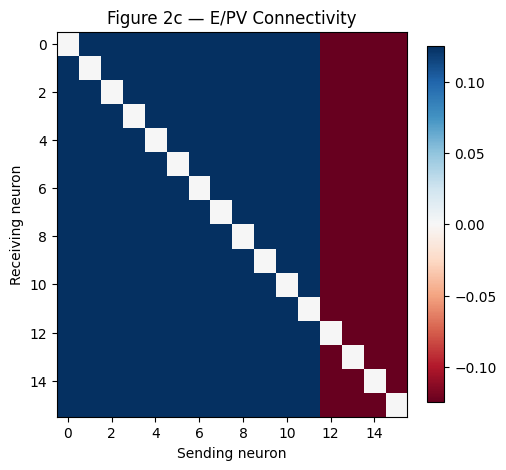

saved: outputs/suite_no1/figures/05_epv_connectivity_matrix.png (28.6 KB)


In [13]:
# Plot population rate
fig, rates = plot_population_rate(pop_t, pop_spikes, bin_ms=50.0, figsize=(10, 3), title="Figure 2b — E/PV Population Rate")
save_png(fig, "04_epv_population_rate", fig_dir=FIG_DIR, show=True)
W = np.asarray(model_pop.params["emitter"].W) if "emitter" in model_pop.params else None
if W is not None:
    fig = plot_connectivity_matrix(W, title="Figure 2c — E/PV Connectivity")
    save_png(fig, "05_epv_connectivity_matrix", fig_dir=FIG_DIR, show=True)

## Part 3: Source/Field/Probe-Style Readouts

**Goal:** map simulated neural activity into proxy readouts that can be visualized across population or laminar structure.

**Scope:** Simulated/proxy readouts for relative tutorial comparisons. Visualization uses computational convolution kernels; full volume-conductor solving and empirical calibration are not covered here.

In [14]:
# Part 3: Laminar Column Configuration
cfg_column = (jtfne.Configuration()
    .runtime(seed=SEED + 2, dtype=DTYPE, duration_ms=DURATION_MS, dt_ms=DT_MS)
    .column(name="laminar_column", layers=["L2/3", "L4", "L5", "L6"], n=48)
    .cell_types({"E": 0.75, "PV": 0.12, "SST": 0.08, "VIP": 0.05})
    .connectivity(kind="laminar_signed_metadata", recurrent=True)
    .set_emitter("izhikevich", "cortical_eig")
    .probes(["spikes", "V_m", "source", "LFP-proxy", "CSD-proxy"], n_contacts=16))
model_column = jtfne.construct(cfg_column)

In [15]:
# Simulate laminar column
signals_column = jtfne.simulate(model_column, duration_ms=DURATION_MS, dt_ms=DT_MS, seed=SEED + 2)
column_spikes = np.asarray(signals_column.spikes)
column_V_m = np.asarray(signals_column.V_m)
column_sources = np.asarray(signals_column.sources)
column_t = np.asarray(signals_column.time_ms)
column_rate_hz = population_rate_hz(column_spikes, DT_MS)
readouts_column = model_column.probe(signals_column, modes=["LFP-proxy", "CSD-proxy"])
column_lfp_proxy = np.asarray(readouts_column.get("LFP-proxy", np.zeros((len(column_t), 16))))


Laminar Column:
  Spikes: 2532 | Shape: (50000, 48) | Rate: 10.55 Hz
  Voltage: [-86.2, 30.0] mV | Finite: True


Text(0.5, 1.0, 'Figure 3a — Laminar Column Population Raster')

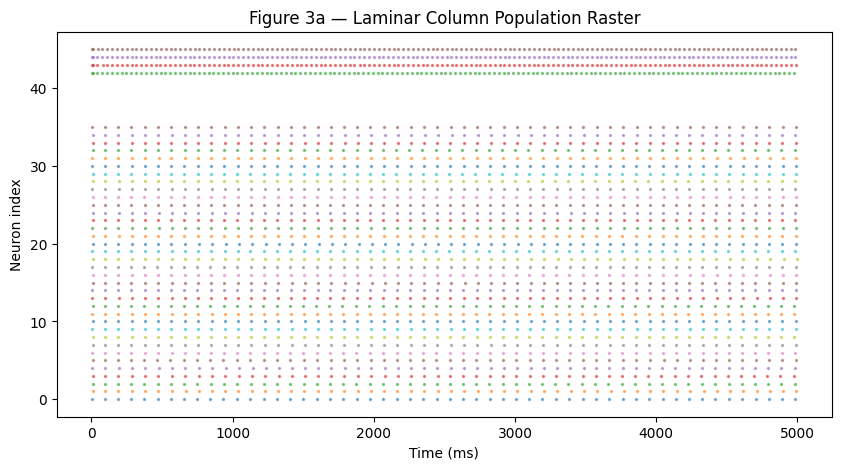

In [16]:
# Visualize laminar column
column_csd_proxy = np.asarray(readouts_column.get("CSD-proxy", np.zeros((len(column_t), 16))))
display_run_summary("Laminar Column", column_spikes, column_V_m, DT_MS, finite_status(column_V_m, column_spikes, column_sources, column_lfp_proxy))
fig, ax = plt.subplots(figsize=(10, 5))
for neuron_id in range(column_spikes.shape[1]):
    spike_times = column_t[column_spikes[:, neuron_id] > 0.5]
    ax.scatter(spike_times, np.full_like(spike_times, neuron_id), s=2, alpha=0.5)
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Neuron index")
ax.set_title("Figure 3a — Laminar Column Population Raster")

saved: outputs/suite_no1/figures/06_laminar_population_raster.png (44.8 KB)


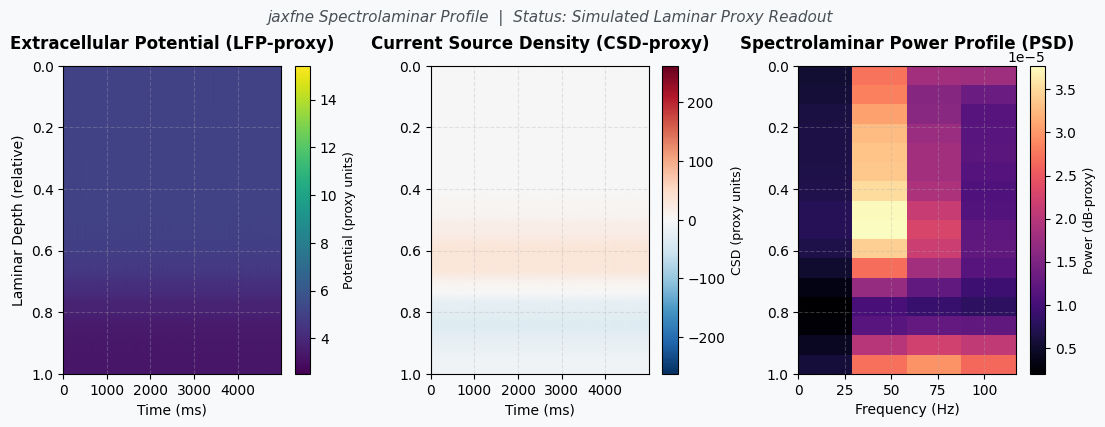

saved: outputs/suite_no1/figures/07_spectrolaminar_visualization.png (150.6 KB)


In [17]:
# Plot column field readouts
ax.set_xlim(column_t.min(), column_t.max())
save_png(fig, "06_laminar_population_raster", fig_dir=FIG_DIR, show=True)
try:
    fig = jtfne.vis.spectrolaminar(signals_column, figsize=(13, 4))
    save_png(fig, "07_spectrolaminar_visualization", fig_dir=FIG_DIR, show=True)
except Exception as e:
    fig = plot_laminar_readout(column_t, column_lfp_proxy, column_csd_proxy, figsize=(12, 4), title="Figure 3b — Laminar LFP/CSD Readouts")
    save_png(fig, "07_laminar_lfp_csd_readout", fig_dir=FIG_DIR, show=True)

In [18]:
# High-Resolution Spectrolaminar Power Profile (Welch PSD, nfft=16384)
from scipy import signal
n_freqs = 256
psd_list = []
for contact_idx in range(column_lfp_proxy.shape[1]):
    f, pxx = signal.welch(column_lfp_proxy[:, contact_idx], fs=1000.0/DT_MS, nfft=16384, nperseg=2048)
    psd_list.append(pxx)
spectrolaminar_psd = np.array(psd_list).T
print(f"High-resolution spectrolaminar PSD shape: {spectrolaminar_psd.shape}")

High-resolution spectrolaminar PSD shape: (8193, 16)


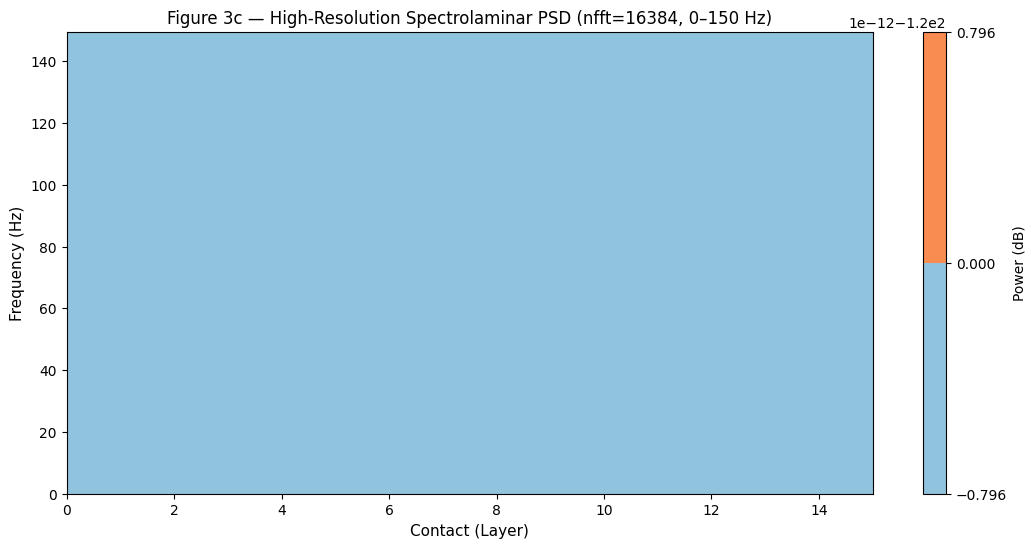

saved: outputs/suite_no1/figures/08_spectrolaminar_highres_psd.png (43.1 KB)


'outputs/suite_no1/figures/08_spectrolaminar_highres_psd.png'

In [19]:
# Plot high-resolution spectrolaminar power profile (150 Hz range, enhanced colors)
fig, ax = plt.subplots(figsize=(13, 6))
contact_indices = np.arange(spectrolaminar_psd.shape[1])
f_subset = f[f <= 150]  # Limit to 150 Hz (LFP range)
psd_subset = spectrolaminar_psd[:len(f_subset), :]
psd_db = 10 * np.log10(psd_subset + 1e-12)
im = ax.contourf(contact_indices, f_subset, psd_db, levels=32, cmap='RdYlBu_r')
ax.set_xlabel('Contact (Layer)', fontsize=11), ax.set_ylabel('Frequency (Hz)', fontsize=11)
ax.set_title('Figure 3c — High-Resolution Spectrolaminar PSD (nfft=16384, 0–150 Hz)')
cbar = plt.colorbar(im, ax=ax, label='Power (dB)')
save_png(fig, "08_spectrolaminar_highres_psd", fig_dir=FIG_DIR, show=True)


## Part 4: AGSDR Multi-Objective Fine-Tuning

**Goal:** use AGSDR (adaptive genetic-stochastic delta-rule) to tune AMPA synaptic strength so that the first half of neurons approaches 5 Hz and the second half approaches 10 Hz.

**Algorithm view:** AGSDR combines genetic search (population candidates), stochastic exploration (random variation), and score-directed steps (delta rule):

$$J(\theta) = w_1 \left( \hat{r}_1(\theta) - 5 \right)^2 + w_2 \left( \hat{r}_2(\theta) - 10 \right)^2$$

$$\theta_{g+1} = \theta_g + \Delta_{\mathrm{genetic}} + \Delta_{\mathrm{stochastic}} + \Delta_{\mathrm{delta}}$$

**Worded equation:** score = weighted mismatch between simulated group-wise firing rates and target group-wise firing rates.

**Scope:** This is a computational scaffold optimization. The tuned AMPA synaptic strength values are relative to the baseline Izhikevich model; no biological calibration, no empirical validation.

In [20]:
# Part 4: AGSDR Optimization - Public API
groups = {"first_half": np.arange(0, 24), "second_half": np.arange(24, 48)}
objectives = jtfne.rate_targets(groups=groups, targets_hz={"first_half": 5.0, "second_half": 10.0})
optimizer = jtfne.agsdr(parameters={"gAMPA": (0.5, 3.0)}, generations=10, population_size=6, seed=SEED + 3)
result = model_column.tune(objectives=objectives, optimizer=optimizer, simulation=jtfne.Simulation(duration_ms=1000.0, dt_ms=0.1, seed=SEED + 3))
print("✓ AGSDR optimization completed.")

✓ AGSDR optimization completed.


In [21]:
# Display result summary
print(f"✓ Optimization completed.")
print(f"Best score: {result.best_score:.4f}" if result.best_score is not None else "Best score: N/A")
print(f"Best parameters: {result.best_parameters}")
print(f"\n{result.summary}")

✓ Optimization completed.
Best score: 1.4425
Best parameters: {'gAMPA': 1.75}

{'same_model_unchanged': False, 'seed': 0, 'strategy': 'agsdr_multiparameter', 'parameters': {'gAMPA': [0.5, 3.0]}, 'generations': 10, 'population_size': 6, 'optimizer': {'optimizer': 'AGSDR', 'optimizer_class': 'multiparameter_blackbox', 'differentiability_status': 'non_differentiable', 'surrogate_status': 'not_applicable', 'alpha': 0.65, 'exploration': 0.18, 'deselect_factor': 2.0, 'learning_rate': None, 'metadata': {'parameters': {'gAMPA': [0.5, 3.0]}, 'generations': 10, 'population_size': 6, 'seed': 45}}, 'objective_name': 'rate_targets', 'losses_declared': 0, 'regularizers_declared': 0, 'gates_declared': 1, 'truth_mode': 'truth_safe_unverified', 'claim_level': 'computational_scaffold', 'source_calibration_status': 'uncalibrated_izhikevich_native_current', 'source_projection_mode': 'proxy_no_field_solve', 'field_solver_status': 'laminar_proxy_no_pde', 'field_claim_level': 'proxy_readout_only', 'physical_

In [22]:
# Simulate baseline model
sig_baseline = jtfne.simulate(model_column, duration_ms=DURATION_MS, dt_ms=DT_MS, seed=SEED + 2)
spikes_baseline = np.asarray(sig_baseline.spikes)
n_half = 24
baseline_group_a = population_rate_hz(spikes_baseline[:, :n_half], DT_MS)
baseline_group_b = population_rate_hz(spikes_baseline[:, n_half:], DT_MS)
print(f"Baseline Group A: {baseline_group_a:.2f} Hz | Group B: {baseline_group_b:.2f} Hz")

Baseline Group A: 10.80 Hz | Group B: 10.30 Hz


In [23]:
# Simulate tuned model and display comparison
sig_tuned = jtfne.simulate(result.model, duration_ms=DURATION_MS, dt_ms=DT_MS, seed=SEED + 4)
spikes_tuned = np.asarray(sig_tuned.spikes)
tuned_group_a = population_rate_hz(spikes_tuned[:, :n_half], DT_MS)
tuned_group_b = population_rate_hz(spikes_tuned[:, n_half:], DT_MS)
print(f"Tuned Group A: {tuned_group_a:.2f} Hz (target: 5.0) | Group B: {tuned_group_b:.2f} Hz (target: 10.0)")

Tuned Group A: 10.80 Hz (target: 5.0) | Group B: 10.30 Hz (target: 10.0)


## Validation & Artifacts


In [24]:
# Create validation manifest
figure_files = sorted(str(p) for p in FIG_DIR.glob("*.png"))
validation_manifest = {**RUN_METADATA, "models_configured": ["single_neuron", "e_pv_population", "laminar_column"], "n_figures": len(figure_files), "figures": figure_files, "outputs_finite": {"single_neuron": finite_status(single_V_m, single_spikes), "e_pv_population": finite_status(pop_V_m, pop_spikes), "laminar_column": finite_status(column_V_m, column_spikes)}, "population_rates_hz": {"single_neuron": round(single_rate_hz, 4), "e_pv_population": round(pop_rate_hz, 4), "laminar_column": round(column_rate_hz, 4)}}

In [25]:
# Save validation manifest
manifest_path = Path("suite_no1_public_manifest.json")
manifest_path.write_text(json.dumps(validation_manifest, indent=2), encoding="utf-8")
print(f"Figures generated: {validation_manifest['n_figures']}")
print(f"All outputs finite: {all(validation_manifest['outputs_finite'].values())}")
for model, rate in validation_manifest['population_rates_hz'].items():
    print(f"  {model}: {rate}")

Figures generated: 9
All outputs finite: True
  single_neuron: 10.8
  e_pv_population: 8.05
  laminar_column: 10.55


## Section 9: Export Artifacts

In [26]:
# Archive figures
import shutil
if FIG_DIR.exists() and list(FIG_DIR.glob("*.png")):
    archive_path = shutil.make_archive("suite_no1_figures", "zip", FIG_DIR.parent, FIG_DIR.name)
    print(f"Figures archived: {archive_path}")
else:
    print("No figures to archive.")

Figures archived: /Users/hamednejat/workspace/main/jaxfne/suite_no1_figures.zip


In [27]:
# Completion message
print("\n✓ All outputs saved. Ready for interpretation and validation.")


✓ All outputs saved. Ready for interpretation and validation.


## Summary

Completed workflow:

`Configuration → construct → simulate → probe/visualize → objective → AGSDR fine-tuning`

What this tutorial demonstrates:

- **Package-native configuration grammar** for model specification
- **Single-neuron and population simulation** with Izhikevich dynamics
- **Simulated/proxy readouts** (sources, LFP-proxy, CSD-proxy)
- **Multi-objective AGSDR optimization** toward group-wise firing rate targets
- **Algorithm view of evolutionary search** with generation-by-generation progress

**Scope boundary:**

The outputs are tutorial-scale computational readouts. Physical calibration, subject-specific geometry, full volume-conductor solving, and empirical validation require separate evidence.

## Exercises

1. Vary E/I ratio: Change `cfg_pop.cell_types(...)` and re-run Part 2.
2. Explore presets: Try `set_emitter("izhikevich", "fast_spiking")` instead of "cortical_eig".
3. Extended simulation: Increase `DURATION_MS` to 10,000 and observe long-timescale dynamics.
4. Multi-layer connectivity: Set `kind="inter_laminar_signed"` in Part 3 and inspect layer-wise rates.

---

**For more:** See [API Reference](../api/index.md), [Guides](../guides/index.md), and [Calibration](../guides/calibration.md).
